In [ ]:
from sympy import *
from sympy.physics.quantum import TensorProduct
import numpy as np
init_printing(pretty_print=True)
a=1
c=3
#a,c = symbols('a,c')


Ground State

In [2]:
g = Matrix([[0], [-(128*a**6*c - 64*a**5*c**2 + 128*a**5*c*np.sqrt(a**2 + a*c + c**2) + 144*a**4*c**3 - 128*a**4*c**2*np.sqrt(a**2 + a*c + c**2) - 128*a**3*c**4 + 160*a**3*c**3*np.sqrt(a**2 + a*c + c**2) + 106*a**2*c**5 - 136*a**2*c**4*np.sqrt(a**2 + a*c + c**2) - 69*a*c**6 + 87*a*c**5*np.sqrt(a**2 + a*c + c**2) + 36*c**7 - 36*c**6*np.sqrt(a**2 + a*c + c**2))/(512*a**7 + 512*a**6*np.sqrt(a**2 + a*c + c**2) + 544*a**5*c**2 - 256*a**5*c*np.sqrt(a**2 + a*c + c**2) - 320*a**4*c**3 + 480*a**4*c**2*np.sqrt(a**2 + a*c + c**2) + 306*a**3*c**4 - 368*a**3*c**3*np.sqrt(a**2 + a*c + c**2) - 202*a**2*c**5 + 250*a**2*c**4*np.sqrt(a**2 + a*c + c**2) + 105*a*c**6 - 123*a*c**5*np.sqrt(a**2 + a*c + c**2) - 36*c**7 + 36*c**6*np.sqrt(a**2 + a*c + c**2))], [-(32*a**5*c - 16*a**4*c**2 + 32*a**4*c*np.sqrt(a**2 + a*c + c**2) + 30*a**3*c**3 - 32*a**3*c**2*np.sqrt(a**2 + a*c + c**2) - 26*a**2*c**4 + 34*a**2*c**3*np.sqrt(a**2 + a*c + c**2) + 19*a*c**5 - 25*a*c**4*np.sqrt(a**2 + a*c + c**2) - 12*c**6 + 12*c**5*np.sqrt(a**2 + a*c + c**2))/(128*a**6 + 128*a**5*np.sqrt(a**2 + a*c + c**2) + 112*a**4*c**2 - 64*a**4*c*np.sqrt(a**2 + a*c + c**2) - 68*a**3*c**3 + 96*a**3*c**2*np.sqrt(a**2 + a*c + c**2) + 54*a**2*c**4 - 68*a**2*c**3*np.sqrt(a**2 + a*c + c**2) - 31*a*c**5 + 37*a*c**4*np.sqrt(a**2 + a*c + c**2) + 12*c**6 - 12*c**5*np.sqrt(a**2 + a*c + c**2))], [0], [-(8*a**3*c - 4*a**2*c**2 + 8*a**2*c*np.sqrt(a**2 + a*c + c**2) + 5*a*c**3 - 8*a*c**2*np.sqrt(a**2 + a*c + c**2) - 6*c**4 + 6*c**3*np.sqrt(a**2 + a*c + c**2))/(32*a**4 + 32*a**3*np.sqrt(a**2 + a*c + c**2) + 18*a**2*c**2 - 16*a**2*c*np.sqrt(a**2 + a*c + c**2) - 11*a*c**3 + 14*a*c**2*np.sqrt(a**2 + a*c + c**2) + 6*c**4 - 6*c**3*np.sqrt(a**2 + a*c + c**2))], [0], [0], [1]])
print(g)

Matrix([[0], [-0.245678061214219], [-0.245678061214220], [0], [-0.245678061214220], [0], [0], [1]])


Normalize the Grund State


In [3]:
import numpy as np

# Given matrix
matrix = np.array(g).astype(np.float64)

# Calculate the L2 norm (which is the square root of the sum of the squares)
l2_norm = np.linalg.norm(matrix)

# Normalize the matrix
normalized_matrix = matrix / l2_norm

# Confirm that the sum of the squares of the elements equals 1
sum_of_squares = np.sum(normalized_matrix**2)

normalized_matrix, sum_of_squares

(array([[ 0.        ],
        [-0.22606222],
        [-0.22606222],
        [ 0.        ],
        [-0.22606222],
        [ 0.        ],
        [ 0.        ],
        [ 0.9201563 ]]),
 0.9999999999999999)

Using Normalized Ground State to Measure E_A

In [4]:
from sympy import *
from sympy.physics.quantum import TensorProduct
init_printing(pretty_print=True)

id= Matrix([[1,0],[0,1]])
Z= Matrix([[1,0],[0,-1]])
X= Matrix([[0,1],[1,0]])
Y= Matrix([[0,-1j],[1j,0]])
Z0= TensorProduct(Z, id, id)
Z1= TensorProduct(id, Z, id)
Z2= TensorProduct(id, id ,Z)
I = TensorProduct(id, id, id)
X0X1 = TensorProduct(X, X, id)
X1X2 = TensorProduct(id, X, X)
X0X2 = TensorProduct(X, id, X)


H_tot= a*(Z0+Z1+Z2)+c*(X0X1+X1X2+X0X2)+(2*sqrt(a**2 + a*c + c**2)+a-c)*I;

Alice and Charlie give energy

In [5]:
from sympy import *

g = normalized_matrix
IX = TensorProduct(X,id,id)
IX2 = TensorProduct(id,X,id)
I = TensorProduct(id, id, id)
Y_b =  TensorProduct(id,id,Y)
Y_c =  TensorProduct(id,Y,id)
gg = .5*(I - IX)
a1 = g.T*gg*H_tot*gg*g
gg2 = .5*(I - IX2)
a2 = g.T*gg*gg2*H_tot*gg2*gg*g

print("{:.2f}".format((a2*2)[0]))
print("{:.2f}".format((a1*2)[0]))

0.80
0.80


Calculate theta


In [6]:
import math
sig_b = 1j*(H_tot*Y_b - Y_b*H_tot)
sig_c = 1j*(H_tot*Y_c - Y_c*H_tot)
nita = g.T*IX*sig_b*g
eta = g.T*Y_b*H_tot*Y_b*g
theta = acos(eta[0]/sqrt(eta[0]*eta[0]+nita[0]*nita[0]))



In [7]:
print("{:.2f}".format(theta)) 

0.19


In [8]:
nita2 = g.T*IX*sig_c*g
eta2 = g.T*Y_c*H_tot*Y_c*g

In [9]:
print("{:.2f}".format(nita2[0]))

1.04


In [10]:
theta2 = acos(eta2[0]/sqrt(eta2[0]*eta2[0]+nita2[0]*nita2[0]))
print("{:.2f}".format(theta2))

0.19


In [11]:
print(eta)

Matrix([[0.226062216627216*I*(-0.226062216627216*I*(1 + 2*sqrt(13)) + 4.11684220988834*I) - 0.226062216627216*I*(0.226062216627216*I*(-3 + 2*sqrt(13)) + 2.76046891012504*I) - 0.226062216627217*I*(0.226062216627217*I*(-3 + 2*sqrt(13)) + 2.76046891012504*I) - 0.920156303375013*I*(0.678186649881652*I + 0.920156303375013*I*(-3 + 2*sqrt(13)))]])


xx is used like - V_a = c * X0X1 + xx/const , 
                  H_a = a * Z_0 + (const * const-xx)/const

In [12]:
const =  (2*sqrt(a**2 + a*c + c**2)+a-c)
xx = c**2*(158329674399744*a**34 - 118747255799808*a**33*c + 158329674399744*a**33*sqrt(a**2 + a*c + c**2) + 880708813848576*a**32*c**2 - 197912092999680*a**32*c*sqrt(a**2 + a*c + c**2) - 1108307720798208*a**31*c**3 + 920291232448512*a**31*c**2*sqrt(a**2 + a*c + c**2) + 2809114770014208*a**30*c**4 - 1464549488197632*a**30*c**3*sqrt(a**2 + a*c + c**2) - 4125384807284736*a**29*c**5 + 3155460932763648*a**29*c**4*sqrt(a**2 + a*c + c**2) + 6845168552509440*a**28*c**6 - 4985993174188032*a**28*c**5*sqrt(a**2 + a*c + c**2) - 9616324401561600*a**27*c**7 + 7879104619610112*a**27*c**6*sqrt(a**2 + a*c + c**2) + 13093904660299776*a**26*c**8 - 11126718370676736*a**26*c**7*sqrt(a**2 + a*c + c**2) - 16526551239622656*a**25*c**9 + 14828650541088768*a**25*c**8*sqrt(a**2 + a*c + c**2) + 19753307757084672*a**24*c**10 - 18440205593739264*a**24*c**9*sqrt(a**2 + a*c + c**2) - 22294888477360128*a**23*c**11 + 21593530250035200*a**23*c**10*sqrt(a**2 + a*c + c**2) + 23849677753417728*a**22*c**12 - 23842959912861696*a**22*c**11*sqrt(a**2 + a*c + c**2) - 24205951642632192*a**21*c**13 + 24884852281049088*a**21*c**12*sqrt(a**2 + a*c + c**2) + 23333300128382976*a**20*c**14 - 24582219723177984*a**20*c**13*sqrt(a**2 + a*c + c**2) - 21372225838055424*a**19*c**15 + 23003534685044736*a**19*c**14*sqrt(a**2 + a*c + c**2) + 18602686537150464*a**18*c**16 - 20398918998491136*a**18*c**15*sqrt(a**2 + a*c + c**2) - 15381883661644800*a**17*c**17 + 17139953133563904*a**17*c**16*sqrt(a**2 + a*c + c**2) + 12073426736447232*a**16*c**18 - 13638115734875136*a**16*c**17*sqrt(a**2 + a*c + c**2) - 8985307444540416*a**15*c**19 + 10265749338274560*a**15*c**18*sqrt(a**2 + a*c + c**2) + 6330083765953824*a**14*c**20 - 7298786722756608*a**14*c**19*sqrt(a**2 + a*c + c**2) - 4212361412258436*a**13*c**21 + 4891311030604320*a**13*c**20*sqrt(a**2 + a*c + c**2) + 2640474759224061*a**12*c**22 - 3081251206538172*a**12*c**21*sqrt(a**2 + a*c + c**2) - 1553676345956619*a**11*c**23 + 1818180648425241*a**11*c**22*sqrt(a**2 + a*c + c**2) + 854374519246257*a**10*c**24 - 1000523956085973*a**10*c**23*sqrt(a**2 + a*c + c**2) - 436644730566837*a**9*c**25 + 510566177620107*a**9*c**24*sqrt(a**2 + a*c + c**2) + 205929966945726*a**8*c**26 - 239874140428011*a**8*c**25*sqrt(a**2 + a*c + c**2) - 88804903586832*a**7*c**27 + 102794413238208*a**7*c**26*sqrt(a**2 + a*c + c**2) + 34595009059680*a**6*c**28 - 39687241422528*a**6*c**27*sqrt(a**2 + a*c + c**2) - 11975083701120*a**5*c**29 + 13574732530176*a**5*c**28*sqrt(a**2 + a*c + c**2) + 3598003784448*a**4*c**30 - 4016691182592*a**4*c**29*sqrt(a**2 + a*c + c**2) - 905886332928*a**3*c**31 + 992057352192*a**3*c**30*sqrt(a**2 + a*c + c**2) + 180404195328*a**2*c**32 - 192900538368*a**2*c**31*sqrt(a**2 + a*c + c**2) - 25476415488*a*c**33 + 26443874304*a*c**32*sqrt(a**2 + a*c + c**2) + 1934917632*c**34 - 1934917632*c**33*sqrt(a**2 + a*c + c**2))/(35184372088832*a**34 + 35184372088832*a**33*sqrt(a**2 + a*c + c**2) + 182518930210816*a**32*c**2 - 17592186044416*a**32*c*sqrt(a**2 + a*c + c**2) - 112150186033152*a**31*c**3 + 178120883699712*a**31*c**2*sqrt(a**2 + a*c + c**2) + 482410726686720*a**30*c**4 - 188016488349696*a**30*c**3*sqrt(a**2 + a*c + c**2) - 534362651099136*a**29*c**5 + 505500470870016*a**29*c**4*sqrt(a**2 + a*c + c**2) + 1001818301661184*a**28*c**6 - 684858305150976*a**28*c**5*sqrt(a**2 + a*c + c**2) - 1286712072339456*a**27*c**7 + 1118246275121152*a**27*c**6*sqrt(a**2 + a*c + c**2) + 1764795619475456*a**26*c**8 - 1501602171060224*a**26*c**7*sqrt(a**2 + a*c + c**2) - 2161279082954752*a**25*c**9 + 1976176729915392*a**25*c**8*sqrt(a**2 + a*c + c**2) + 2547679708053504*a**24*c**10 - 2400973691551744*a**24*c**9*sqrt(a**2 + a*c + c**2) - 2826839697391616*a**23*c**11 + 2764102304792576*a**23*c**10*sqrt(a**2 + a*c + c**2) + 2981106315952128*a**22*c**12 - 3001956452794368*a**22*c**11*sqrt(a**2 + a*c + c**2) - 2985382115278848*a**21*c**13 + 3087343539978240*a**21*c**12*sqrt(a**2 + a*c + c**2) + 2842860958384128*a**20*c**14 - 3009046017736704*a**20*c**13*sqrt(a**2 + a*c + c**2) - 2574930886393856*a**19*c**15 + 2781573882445824*a**19*c**14*sqrt(a**2 + a*c + c**2) + 2218370546098176*a**18*c**16 - 2439316034355200*a**18*c**15*sqrt(a**2 + a*c + c**2) - 1817129687646208*a**17*c**17 + 2028962456756224*a**17*c**16*sqrt(a**2 + a*c + c**2) + 1414085557352960*a**16*c**18 - 1599661813641216*a**16*c**17*sqrt(a**2 + a*c + c**2) - 1044183609838080*a**15*c**19 + 1194132767383040*a**15*c**18*sqrt(a**2 + a*c + c**2) + 730407032189248*a**14*c**20 - 842668072338688*a**14*c**19*sqrt(a**2 + a*c + c**2) - 482937550132992*a**13*c**21 + 560933430345792*a**13*c**20*sqrt(a**2 + a*c + c**2) + 300984032223126*a**12*c**22 - 351247296131616*a**12*c**21*sqrt(a**2 + a*c + c**2) - 176195264111106*a**11*c**23 + 206171268565050*a**11*c**22*sqrt(a**2 + a*c + c**2) + 96454377273016*a**10*c**24 - 112931946258123*a**10*c**23*sqrt(a**2 + a*c + c**2) - 49102371757614*a**9*c**25 + 57401274672028*a**9*c**24*sqrt(a**2 + a*c + c**2) + 23080689855242*a**8*c**26 - 26878494278327*a**8*c**25*sqrt(a**2 + a*c + c**2) - 9925896325872*a**7*c**27 + 11486957224224*a**7*c**26*sqrt(a**2 + a*c + c**2) + 3858266039904*a**6*c**28 - 4425394106304*a**6*c**27*sqrt(a**2 + a*c + c**2) - 1333330809984*a**5*c**29 + 1511253206784*a**5*c**28*sqrt(a**2 + a*c + c**2) + 400152192768*a**4*c**30 - 446686451712*a**4*c**29*sqrt(a**2 + a*c + c**2) - 100680910848*a**3*c**31 + 110255468544*a**3*c**30*sqrt(a**2 + a*c + c**2) + 20044910592*a**2*c**32 - 21433393152*a**2*c**31*sqrt(a**2 + a*c + c**2) - 2830712832*a*c**33 + 2938208256*a*c**32*sqrt(a**2 + a*c + c**2) + 214990848*c**34 - 214990848*c**33*sqrt(a**2 + a*c + c**2))

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

import numpy as np


from qiskit.quantum_info import Statevector

sv =  Statevector.from_label('000')
sv.data[[1,2,4]]=g[1,0]
sv.data[0]=0
sv.data[7]=g[7,0]

phi2 = .19


from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
qc1 = QuantumCircuit(3,3)
qc1.initialize(sv.data,[0,1,2])
qc1.draw(output='mpl')
qc1.h(0)
qc1.measure(0,0)
qc1.barrier()
qc1.draw(output='mpl')
qc2 = qc1.copy()

qc1.ry(-phi2,1).c_if(qc1.cregs[0],1)
qc1.ry(phi2,1).c_if(qc1.cregs[0],0)
qc1.h(1)
qc1.measure(1,1)
qc1.barrier()



qc1.ry(-phi2,2).c_if(qc1.cregs[0],1)
qc1.ry(phi2,2).c_if(qc1.cregs[0],0)
qc1.ry(-phi2,1).c_if(qc1.cregs[1],1)
qc1.ry(phi2,1).c_if(qc1.cregs[1],0)


qc1.h(2)
qc1.measure(2,2)
qc1.draw(output='mpl')



In [50]:
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator2 = AerSimulator()
comp_circuit2 = transpile(qc1, simulator2)
job2 = simulator2.run(comp_circuit2)
result2 = job2.result()

counts2 = result2.get_counts()

plot_histogram(counts2)
from sympy import *
from sympy.physics.quantum import TensorProduct

#en_A = (h**2)/np.sqrt(h**2+k**2)
en_V2 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V2 += c*(-1)**int(bit_srting[1])*(-1)**int(bit_srting[0])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


en_V3 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V3 += c*(-1)**int(bit_srting[2])*(-1)**int(bit_srting[0])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots

en_V4 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V4 += c*(-1)**int(bit_srting[2])*(-1)**int(bit_srting[1])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots

qc2.ry(-phi2,1).c_if(qc2.cregs[0],1)
qc2.ry(phi2,1).c_if(qc2.cregs[0],0)
qc2.measure(1,1)

qc2.ry(-phi2,2).c_if(qc2.cregs[0],1)
qc2.ry(phi2,2).c_if(qc2.cregs[0],0)
qc2.measure(2,2)

qc2.draw(output='mpl')
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
comp_circuit = transpile(qc2, simulator)
job = simulator.run(comp_circuit)
result = job.result()

counts = result.get_counts()


en_h1 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
en_h2 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_h1 += a*(-1)**int(bit_srting[1])*count/n_shots
    en_h2 += a*(-1)**int(bit_srting[2])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


tot1=en_h1+en_V2
tot2=en_h2+en_V3
print("{:.2f}".format(en_h1))  
print("{:.2f}".format(en_V2)) 
print("{:.2f}".format(en_h2))  
print("{:.2f}".format(en_V3)) 
 

print("{:.2f}".format(tot1))  
print("{:.2f}".format(tot2)) 


0.11
-0.39
-0.03
-0.22
-0.28
-0.25


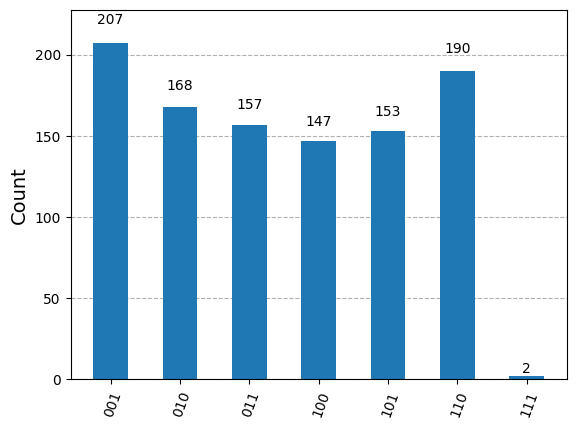

In [64]:
plot_histogram(counts2)

0.10
-0.31
-0.00
-0.10
-0.20
-0.11


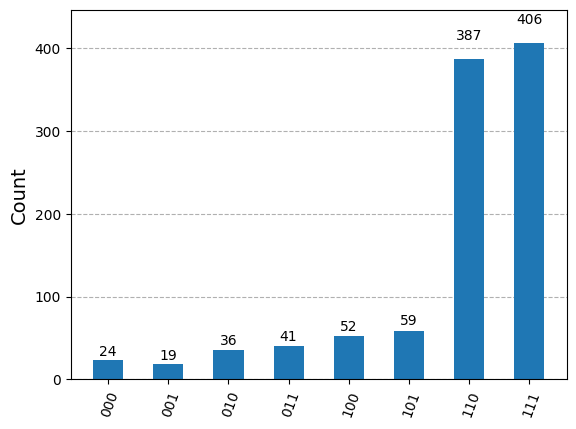

In [15]:
plot_histogram(counts)

In [52]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

import numpy as np


from qiskit.quantum_info import Statevector

sv =  Statevector.from_label('000')
sv.data[[1,2,4]]=g[1,0]
sv.data[0]=0
sv.data[7]=g[7,0]

phi2 = .19


from qiskit import QuantumRegister, ClassicalRegister,QuantumCircuit
from qiskit.visualization import plot_histogram

qreg = QuantumRegister(3, 'q')

# Create a classical register with 2 classical bits
creg = ClassicalRegister(3, 'c')

# Create a quantum circuit with the quantum and classical registers
qc1 = QuantumCircuit(qreg, creg)
qc1.initialize(sv.data,[0,1,2])
qc1.draw(output='mpl')
qc1.h(0)
qc1.measure(0,0)
qc1.barrier()
qc1.draw(output='mpl')
qc2 = qc1.copy()

qc1.ry(phi2,1).c_if(creg[0],0)
qc1.ry(-phi2,1).c_if(creg[0],1)
qc1.h(1)
qc1.measure(1,1)
qc1.barrier()



qc1.ry(-phi2,2).c_if(creg[0],1)
qc1.ry(phi2,2).c_if(creg[0],0)
qc1.ry(phi2,1).c_if(creg[1],1)
qc1.ry(-phi2,1).c_if(creg[1],0)


qc1.h(2)
qc1.measure(2,2)
qc1.draw(output='mpl')
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
simulator2 = AerSimulator()
comp_circuit2 = transpile(qc1, simulator2)
job2 = simulator2.run(comp_circuit2)
result2 = job2.result()
counts2 = result2.get_counts()
plot_histogram(counts2)
from sympy import *
from sympy.physics.quantum import TensorProduct
#en_A = (h**2)/np.sqrt(h**2+k**2)
en_V2 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V2 += c*(-1)**int(bit_srting[1])*(-1)**int(bit_srting[0])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


en_V3 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V3 += c*(-1)**int(bit_srting[2])*(-1)**int(bit_srting[0])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots

en_V4 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V4 += c*(-1)**int(bit_srting[2])*(-1)**int(bit_srting[1])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots

qc2.ry(-phi2,1).c_if(qc2.cregs[0],0)
qc2.ry(phi2,1).c_if(qc2.cregs[0],1)
qc2.measure(1,1)

qc2.ry(-phi2,2).c_if(creg[0],0)
qc2.ry(phi2,2).c_if(creg[0],1)
qc2.ry(phi2,1).c_if(creg[1],0)
qc2.ry(-phi2,1).c_if(creg[1],1)
qc2.measure(2,2)

qc2.draw(output='mpl')
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
comp_circuit = transpile(qc2, simulator)
job = simulator.run(comp_circuit)
result = job.result()

counts = result.get_counts()


en_h1 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
en_h2 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
en_h3 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_h1 += a*(-1)**int(bit_srting[1])*count/n_shots
    en_h2 += a*(-1)**int(bit_srting[2])*count/n_shots
    en_h2 += a*(-1)**int(bit_srting[0])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


tot1=en_h1+en_V2
tot2=en_h2+en_V3
#print("h1 "+"{:.2f}".format(en_h1))  
print("v1 "+"{:.2f}".format(en_V2)) 
#print("h2 "+"{:.2f}".format(en_h2))  
print("v2 "+"{:.2f}".format(en_V3)) 
#print("h3 "+"{:.2f}".format(en_h3))  
print("v3 "+"{:.2f}".format(en_V4)+"\n") 

print("{:.2f}".format(tot1))  
print("{:.2f}".format(tot2)) 


v1 -0.56
v2 -0.38
v3 0.77

-0.60
-0.39


Ignore the collaped ones

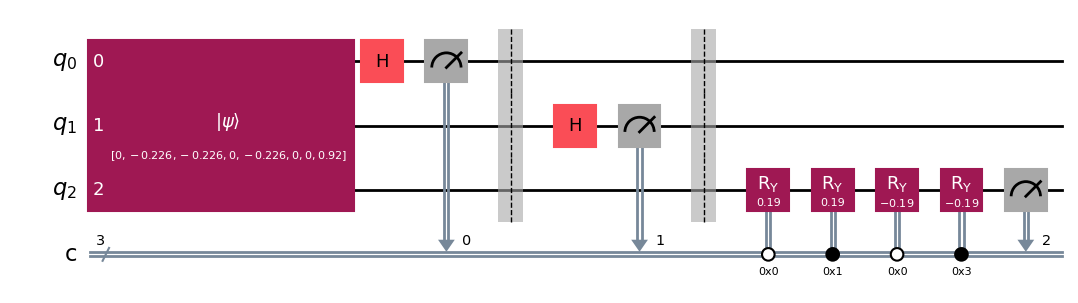

In [288]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

import numpy as np


from qiskit.quantum_info import Statevector

sv =  Statevector.from_label('000')
sv.data[[1,2,4]]=g[1,0]
sv.data[0]=0
sv.data[7]=g[7,0]

phi2 = .19
phi = 45

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
qc1 = QuantumCircuit(3,3)
qc1.initialize(sv.data,[0,1,2])
qc1.draw(output='mpl')
qc1.h(0)
qc1.measure(0,0)
qc1.barrier()
qc1.draw(output='mpl')

qc1.h(1)
qc1.measure(1,1)
qc1.barrier()


qc1.ry(phi2,2).c_if(qc1.cregs[0],0)
qc1.ry(phi2,2).c_if(qc1.cregs[0],1)
qc1.ry(-phi2,2).c_if(qc1.cregs[0],0)
qc1.ry(-phi2,2).c_if(qc1.cregs[0],3)


qc2 = qc1.copy()

qc2.measure(2,2)
qc2.draw(output='mpl')


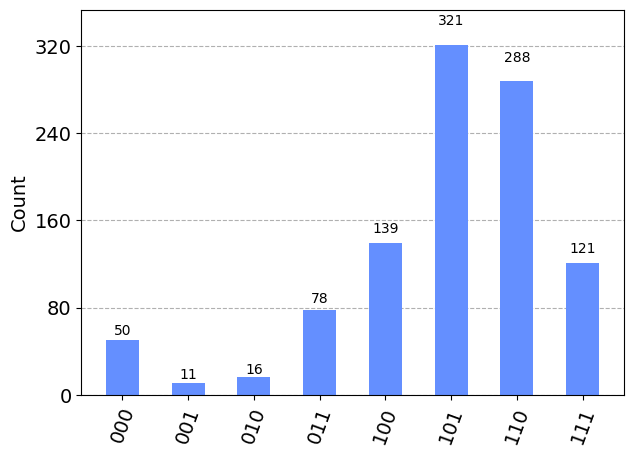

In [289]:
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime.fake_provider import FakePerth
simulator = AerSimulator.from_backend(FakePerth())
comp_circuit = transpile(qc2, simulator)
job = simulator.run(comp_circuit)
result = job.result()

counts = result.get_counts()
plot_histogram(counts)




In [290]:
en_V1 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V1 += a*(-1)**int(bit_srting[2])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


tot=en_V1+en_V2+en_V3
print("{:.2f}".format(en_V1))  
print("{:.2f}".format(en_V2))  
print("{:.2f}".format(en_V3))  

print("{:.2f}".format(tot))  

-0.91
0.66
1.24
0.98


In [ ]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from sympy import sqrt

import multiprocessing as mp



sv = Statevector.from_label('000')
sv.data[[1, 2, 4]] = g[1, 0]
sv.data[0] = 0
sv.data[7] = g[7, 0]

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.visualization import plot_histogram

qreg = QuantumRegister(3, 'q')

# Create a classical register with 2 classical bits
creg = ClassicalRegister(3, 'c')

# Create a quantum circuit with the quantum and classical registers
qc1 = QuantumCircuit(qreg, creg)
qc1.initialize(sv.data, [0, 1, 2])

qc1.h(0)
qc1.measure(0, 0)
qc1.barrier()

qc1.h(1)
qc1.measure(1, 1)
qc1.barrier()

phi2 = .19
qc1.ry(phi2, 2).c_if(creg[0], 0)
qc1.ry(phi2, 2).c_if(creg[0], 2)
qc1.ry(-phi2, 2).c_if(creg[0], 3)
qc1.ry(-phi2, 2).c_if(creg[0], 1)

qc2 = qc1.copy()

# First simulation
qc1.h(2)
qc1.measure(2, 2)
simulator = AerSimulator()
comp_circuit = transpile(qc1, simulator)
job = simulator.run(comp_circuit)
result = job.result()
counts = result.get_counts()

en_V2 = xx / (3 * (2*sqrt(a**2 + a*c + c**2) + a - c))
en_V3 = en_V2

for bit_str, count in counts.items():
    bit_string = bit_str[::-1]
    en_V2 += c * (-1)**int(bit_string[2]) * (-1)**int(bit_string[1]) * count / n_shots
    en_V3 += c * (-1)**int(bit_string[2]) * (-1)**int(bit_string[0]) * count / n_shots



# Second simulation
qc2.measure(2, 2)
comp_circuit2 = transpile(qc2, simulator)
job2 = simulator.run(comp_circuit2)
result2 = job2.result()
counts2 = result2.get_counts()

en_V1 = (5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx) / (3 * (2*sqrt(a**2 + a*c + c**2) + a - c))
n_shots = 1024

for bit_str, count in counts2.items():
    bit_string = bit_str[::-1]
    en_V1 += a * (-1)**int(bit_string[2]) * count / n_shots

   


tot=en_V1+en_V2+en_V3
print("{:.2f}".format(en_V1))  
print("{:.2f}".format(en_V2))  
print("{:.2f}".format(en_V3))  

print("{:.2f}".format(tot))  


0.04
0.18
-0.34
-0.12


2 sender : 1 receiver


In [14]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from sympy import sqrt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

import multiprocessing as mp

sv =  Statevector.from_label('000')
sv.data[[1,2,4]]=g[1,0]
sv.data[0]=0
sv.data[7]=g[7,0]


from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

qreg = QuantumRegister(3, 'q')

# Create a classical register with 2 classical bits
creg = ClassicalRegister(3, 'c')

# Create a quantum circuit with the quantum and classical registers
qc1 = QuantumCircuit(qreg, creg)
qc1.initialize(sv.data,[0,1,2])
qc1.draw(output='mpl')
qc1.h(qreg[0])
qc1.measure(qreg[0],creg[0])
qc1.barrier()
qc1.draw(output='mpl')

qc1.h(qreg[1])
qc1.measure(qreg[1],creg[1])
qc1.barrier()

phi2 = .18
qc1.ry(-phi2,2).c_if(creg[0],1)
qc1.ry(phi2,2).c_if(creg[0],0)
qc1.ry(-phi2,2).c_if(creg[1],1)
qc1.ry(phi2,2).c_if(creg[1],0)

qc2 = qc1.copy()

qc1.h(qreg[2])
qc1.measure(qreg[2],creg[2])
qc1.draw(output='mpl')
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator2 = AerSimulator()
comp_circuit2 = transpile(qc1, simulator2)
job2 = simulator2.run(comp_circuit2)
result2 = job2.result()

counts2 = result2.get_counts()

plot_histogram(counts2)
from sympy import *
from sympy.physics.quantum import TensorProduct

#en_A = (h**2)/np.sqrt(h**2+k**2)
en_V2 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V2 += c*(-1)**int(bit_srting[1])*(-1)**int(bit_srting[2])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


en_V3 = ((xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts2.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_V3 += c*(-1)**int(bit_srting[2])*(-1)**int(bit_srting[0])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots



qc2.measure(qreg[2],creg[2])

qc2.draw(output='mpl')
from qiskit import QuantumCircuit,  transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
comp_circuit = transpile(qc2, simulator)
job = simulator.run(comp_circuit)
result = job.result()

counts = result.get_counts()


en_h1 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
en_h2 = ((5*a**2 + 2*a*c + 4*a*sqrt(a**2 + a*c + c**2) + 5*c**2 - 4*c*sqrt(a**2 + a*c + c**2) - xx)/(3*(2*sqrt(a**2 + a*c + c**2)+a-c)))
n_shots = 1024
cal = 0

for bit_srt , count in counts.items():
    bit_srting =  bit_srt[::-1]
    #en_A += h*(-1)**int(bit_srting[0])*count/n_shots
    en_h2 += a*(-1)**int(bit_srting[2])*count/n_shots
    #cal += (1 - 2 * int(bit_srting[0])) * (1 - 2 * int(bit_srting[1])) * count / n_shots


tot=en_h2+en_V2+en_V3
print("{:.2f}".format(en_h2))  
print("{:.2f}".format(en_V2))  
print("{:.2f}".format(en_V3))  

print("{:.2f}".format(tot))  


0.13
-0.12
-0.04
-0.03


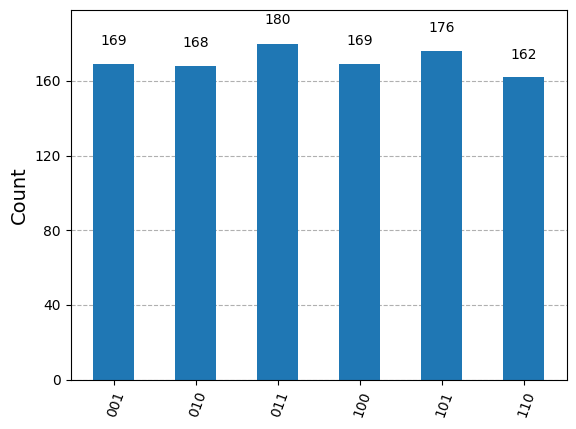

In [15]:
plot_histogram(counts2)

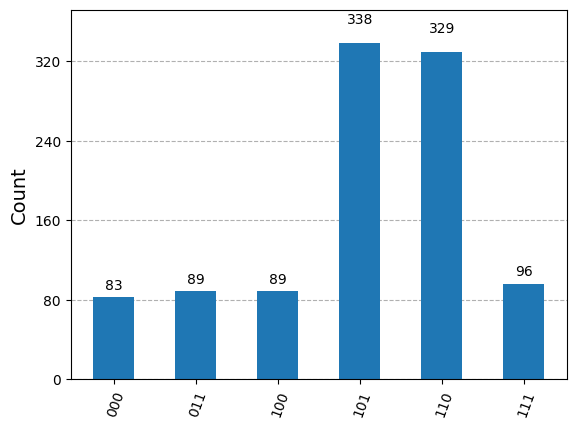

In [16]:
plot_histogram(counts)